<a href="https://colab.research.google.com/github/juanpajedrez/learn_rag_Huggingface/blob/main/Agentic_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries, API Keys and Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/RAG Bootcamp/Advanced RAG/Agentic RAG

[Errno 2] No such file or directory: '/content/drive/MyDrive/RAG Bootcamp/Advanced RAG/Agentic RAG'
/content


In [ ]:
!pip install langchain-community langchain-openai unstructured faiss-cpu langgraph msoffcrypto-tool -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 24.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [ ]:
from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY_RAG')

In [ ]:
from langchain_community.document_loaders import UnstructuredExcelLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.output_parsers import StrOutputParser

from typing import List
from typing_extensions import TypedDict
from IPython.display import display, Image

from langgraph.graph import StateGraph, END

We use UnstructuredExcelLoader to load data from the Excel file containing the restaurant menu. The mode="elements" parameter ensures the data is loaded as individual elements.

In [ ]:
# Specify the path to the Excel file containing the menu
file = 'dim sum montijo.xlsx'

# Create an instance of the loader with the specified mode
loader = UnstructuredExcelLoader(file, mode="elements")

# Load the data from the Excel file
data = loader.load()

We create embeddings for the menu data using OpenAIEmbeddings. FAISS is used to create a vector store from the documents, enabling efficient similarity search.



In [ ]:
# Initialize the embeddings model with the OpenAI API key
embeddings = OpenAIEmbeddings(openai_api_key=api_key)

# Create a vector store (FAISS) from the documents using the embeddings
db = FAISS.from_documents(data, embeddings)

In [ ]:
# Set the model
MODEL = "gpt-5-nano"

# Process

In [ ]:
# Define the TypedDict to store the agent's state
class AgentState(TypedDict):
  start: bool
  conversation: int #conversation turns
  question: str # customer's questions
  answer: str # answer the the question
  topic: bool
  documents: list # list of retrieved docs
  recursion_limit: int # limits endless loops
  memory: list # conversation history
  continue_chat: bool

In [ ]:
# Define the greeting node
def greetings(state):
  # greet the customer
  print("Hello! Welcome to the restaurant. I will be your waiter. How can I help you?")

  # capture the user input
  user_input = input()

  # Update the state
  state['question'] = user_input
  state['conversation'] = 1
  state['memory'] = [user_input]

  return state

In [ ]:
def check_question(state):
  # Get the customer's question from state
  question = state['question']
  memory = state['memory']

  # Define the system prompt
  system_prompt = """
    You are a grader evaluating the appropriateness of a customer's question or prompt to a waiter or waitress in a restaurant.
    Assess if the question is suitable to ask the restaurant staff and if the customer shows interest in continuing the conversation.
    Respond with "True" if the question is appropriate or on topic for the restaurant staff or indicates the customer is asking a question or giving you information.
    Otherwise respond with "False".
    Provide only "True" or "False" in your response.
    """

  # Create the prompt template
  TEMPLATE = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "Customer question: {question},\nConversation History:{memory}"),])

  # format the prompt
  prompt = TEMPLATE.format(memory = memory, question = question)

  # Initialize the LLM
  model = ChatOpenAI(api_key=api_key, model = MODEL)

  # Invoke the answer
  response_text = model.invoke(prompt)
  # Update the state topic
  state['topic'] = response_text.content.strip()

  return state

In [ ]:
# Function to check the conversation
def topic_router(state):
  topic = state['topic']

  if topic == "True":
    return "on_topic"
  else:
    return "off_topic"

In [ ]:
# Define the off_topic response
def off_topic_response(state):
  print("I apologize. I cannot answer that.")

In [ ]:
# Function to retrieve documents
def retrieved_docs(state):
  # Combine the conversation history
  conversation = "\n".join(state['memory'])

  # retrieve the chunks
  docs_faiss = db.similarity_search(conversation, k =10)

  # Store the documents
  state['documents'] = [doc.page_content for doc in docs_faiss]

  return state

In [ ]:
# Build function to tgenerate
def generate_answer(state):
  # initialize the model
  model = ChatOpenAI(api_key=api_key, model = MODEL)

  # include the inputs
  question = state['question']
  documents = state['documents']
  memory = state['memory']

  # Define the system prompt
  system_prompt = """
  You are a waiter at a restaurant tasked with answering the customer's question.
  Answer the question in the manner of a waiter, avoiding being too verbose.
  Do not include "waiter" or refer to yourself explicitly in your answer.
  Answer in English"""

  # Create a prompt template
  TEMPLATE = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "Context: {documents},\nConversation history: {memory},\nCustomer Question: {question}")])

  # Format the template
  prompt = TEMPLATE.format(documents = documents, memory = memory, question = question)

  # Invoke the model
  response_text = model.invoke(prompt)

  # Update the state with the models's response
  state['answer'] = response_text.content.strip()
  #print(state['answer'])

  return state

In [ ]:
def improve_answer(state):
  # get the model
  model = ChatOpenAI(api_key=api_key, model = MODEL)

  # Extract the information
  question = state['question']
  answer = state['answer']

  # Define the system prompt
  system_prompt = f""" based on the {question},
        Improve the answer from a waiter.
        Make it clearer, more polite, and concise.
        Do NOT add new information.
        """

  # Build the template
  TEMPLATE = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{answer}")])

  # Format the Template
  prompt = TEMPLATE.format(answer = answer)

  # Invoke the model
  improved_response = model.invoke(prompt)

  # Store the answer
  state['answer'] = improved_response.content.strip()
  state['memory'].append(improved_response.content.strip())
  print(state['answer'])

  return state

In [ ]:
# Define function to figure out if we need another conversation round
def further_question(state):
  print("Would you like to ask another question?")
  user_input = input()

  # update the conversation memory
  state['memory'].append(user_input)
  state['conversation'] += 1
  state['question'] = user_input

  # simple exit condition
  if user_input.lower() in ["no", "thanks", "that's all", "thank you"]:
    state['continue_chat'] = False
  else:
    state['continue_chat'] = True

  return state

In [ ]:
# define a conditional router
def continue_router(state):
  if state['continue_chat']:
    return  "continue"
  return "end"

# Workflow

In [ ]:
# Initialize a StateGraph
workflow = StateGraph(AgentState)

# Add the functions as nodes
workflow.add_node("greetings", greetings)
workflow.add_node("check_question", check_question)
workflow.add_node("retrieved_docs", retrieved_docs)
workflow.add_node("off_topic_response", off_topic_response)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("improve_answer", improve_answer)
workflow.add_node("further_question", further_question)

# Add an entry point
workflow.set_entry_point("greetings")

# Connecting the nodes (edges)
workflow.add_edge("greetings", "check_question")
workflow.add_edge("retrieved_docs", "generate_answer")
workflow.add_edge("generate_answer", "improve_answer")
workflow.add_edge("improve_answer", "further_question")

# Conditional edges
workflow.add_conditional_edges(
    "check_question",
    topic_router,
    {
        "on_topic": "retrieved_docs",
        "off_topic": "off_topic_response"
    }
)

workflow.add_conditional_edges(
    "further_question",
    continue_router,
    {
        "continue": "check_question",
        "end": END
    }
)

workflow.add_edge("off_topic_response", END)

# Compile the workflow
app = workflow.compile()

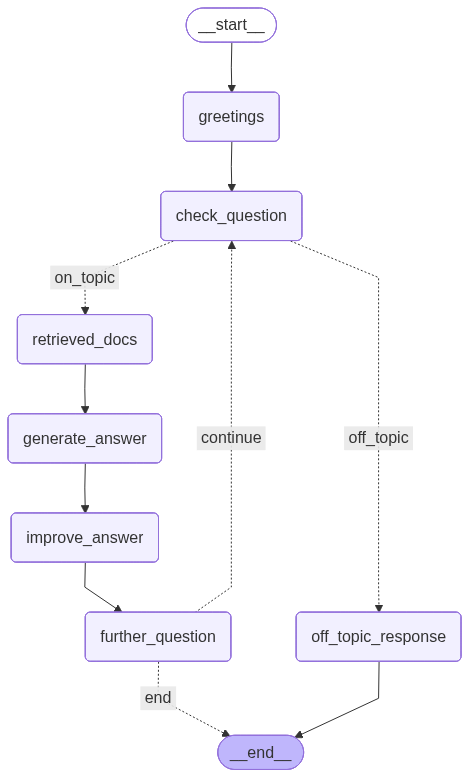

In [ ]:
# Display the workflow
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# test the app
result = app.invoke({"start": True}, {"recursion_limit": 50})

Hello! Welcome to the restaurant. I will be your waiter. How can I help you?
anything vegetarian?
Certainly. Here are our vegetarian options:

- Vegetarian Soup — 3,95
- Steamed Paksoy — 2,40
- Steamed Paksoy with Coriander — 2,40
- Green Jiaozi (Paksoi & Shiitake) — 4,50
- Vegetable Gyoza — 4,50
- Bao de Tofu (Tofu Bao) — 4,70
- Vegetable Crepes — 4,90
- Shui Jing Kao (Bamboo, Mushroom & Vegetables) — 4,50
- White Rice — 1,95

Would you like me to place an order or help with substitutions?
Would you like to ask another question?
Help with substitutions
Certainly—here are substitution options to fit different needs:

- Fully vegetarian/vegan options (pick any):
  - Vegetarian Soup — 3.95
  - Steamed Paksoy — 2.40
  - Steamed Paksoy with Coriander — 2.40
  - Green Jiaozi (Paksoi & Shiitake) — 4.50
  - Vegetable Gyoza — 4.50
  - Bao de Tofu (Tofu Bao) — 4.70
  - Vegetable Crepes — 4.90
  - Shui Jing Kao (Bamboo, Mushroom & Vegetables) — 4.50
  - White Rice — 1.95

- Substituting meat dis

GraphRecursionError: Recursion limit of 10 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT